# Order Simulation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.Load Customer and Restaurant Data

In [42]:
df_customers = pd.read_csv('customers_dummy.csv')
df_rest = pd.read_csv('EDA_restaurants.csv') 

In [30]:
df_customers.head(2)


,customer_id,identity_segment,engagement_tier,age,income,cost_preference,preferred_price_tier,group_size,explore_prob,preferred_rest_type,order_frequency_days,base_churn_hazard,location
0,1000001,Couple,occasional,43,59373,631.0,Mid-range,1,0.3,Fine Dining,27.8,0.06,Whitefield
1,1000002,Office Worker,occasional,36,87255,365.0,Budget,2,0.2,Cafe,4.2,0.06,HSR


### 2. Prepare Restaurant Dataset

Assign a unique restaurant_id to each restaurant so that simulated orders can reference specific restaurants.

In [43]:
df_rest = df_rest.reset_index(drop = True)
df_rest['restaurant_id'] = 'R'+ df_rest.index.astype(str).str.zfill(5)
df_rest.to_csv("restaurants.csv", index=False)

Then the cell that moves restaurant_id to the first column.

In [45]:
col = df_rest.pop("restaurant_id")     # removes the column AND gives it back to you
df_rest.insert(0, "restaurant_id", col) # re-inserts it at position 0 (the very front)

In [107]:
df_rest.to_csv("restaurants.csv", index=False)

In [104]:
len(df_rest)

51065

Remove restaurant fields that are not required for order simulation.

In [48]:
df_rest = df_rest.drop(columns=["address", 'name', 'listed_in(city)'])

In [106]:
df_rest.head(2)

,restaurant_id,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,listed_in(type),popularity_score,appeal_score
0,R00000,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,0.324400,0.698676
1,R00001,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,0.324828,0.699369


In [49]:
df_rest.isnull().sum()

restaurant_id          0
online_order           0
book_table             0
rate                9863
votes                  0
location               0
rest_type              0
cuisines               0
cost                   0
listed_in(type)        0
popularity_score    9863
appeal_score           0
dtype: int64

### Simulation Parameters

In [11]:
seed = 88
rng = np.random.default_rng(seed)
SIMULATION_DAYS = 180 #approx 6 months into future

### Restaurant selection function

In [ ]:
def choose_restaurant(customers, df_restaurants):

    pool = df_restaurants[df_restaurants['online_order'] == 1] 

    if rng.random()<customers['explore_prob']:
        candidates = pool
    
    else:
        candidates = pool[pool['rest_type'] == customers['preferred_rest_type']]
        if len(candidates) == 0:
            candidates = pool

    # cost match, closer to their preferred cost means more likely 

    cost_diff = np.abs(candidates["cost"] - customers['cost_preference'])
    cost_weight = np.exp(-cost_diff/300)  # exponent to punish the unlkely price range more

    # combining with appeal score of restaurant

    weights = candidates['appeal_score'].values*cost_weight
    weights = weights/weights.sum()

    chosen_idx = rng.choice(candidates.index.values, p=weights)
    return df_restaurants.loc[chosen_idx]


### 5. Order simulation function

In [92]:
def order_simulation(customer):
    '''Simulating one customer, seeing how he pwerforms for a period of time'''
    orders=[]
    time = 0.0
    hazard = customer['base_churn_hazard']

    order_frequency_days = max(customer["order_frequency_days"], 1)  # avoiding zero , so division wont break

    daily_hazard = hazard / order_frequency_days


    while time<SIMULATION_DAYS:
        # NEW random gap each cycle, centered on THIS customer's pace
        # (gamma needs scale, so we divide their mean by shape=2)
        gap = rng.gamma(shape=2, scale=order_frequency_days / 2)
        
        time += gap
        if time >= SIMULATION_DAYS:
            break

        # churn check -- probabilistic, not a hard cutoff
        churn_prob_this_gap = 1 - (1 - daily_hazard) ** gap
        if rng.random() < churn_prob_this_gap:
            break   # customer churns here, stop generating orders for them

        restaurant = choose_restaurant(customer, df_rest)

        # order value: lognormal, centered around the restaurant's own cost
        # (right-skewed: usually close to the menu price, occasionally much higher)
        order_value = rng.lognormal(mean=np.log(restaurant["cost"]), sigma=0.3)

        orders.append({
            "customer_id": customer["customer_id"],
            "order_day": round(time, 1),
            "restaurant_id": restaurant.get("restaurant_id", None),
            "rest_type": restaurant["rest_type"],
            "cuisine": restaurant["cuisines"],
            "order_value": round(order_value, 2),
            "group_size": customer["group_size"],
        })

    return orders    


### 6. Run Simulation

In [ ]:
all_orders = []
for _, customer in df_customers.iterrows():
    all_orders.extend(order_simulation(customer))

df = pd.DataFrame(all_orders)   
df.to_csv('order_simulation(1).csv', index=False)



### 7. Validation

In [66]:
df.head(5)

,customer_id,order_day,restaurant_id,rest_type,cuisine,order_value,group_size
0,1000001,12.4,R00080,Fine Dining,"Seafood, North Indian, Chinese, Andhra, Biryan...",659.78,1
1,1000001,57.2,R18643,Cafe,"Cafe, Italian, Tex-Mex, Fast Food, Burger",375.91,1
2,1000001,71.7,R45626,Casual Dining,"North Indian, South Indian, Chinese",1016.69,1
3,1000001,110.8,R00080,Fine Dining,"Seafood, North Indian, Chinese, Andhra, Biryan...",451.86,1
4,1000001,161.6,R28691,Quick Bites,Healthy Food,502.17,1


In [105]:
len(df)

164499

In [53]:
df.describe()

,customer_id,order_day,order_value,group_size
count,1.620890e+05,162089.000000,162089.000000,162089.000000
mean,1.005031e+06,68.309810,663.833652,1.951052
std,2.887819e+03,50.289275,512.327975,1.282154
min,1.000001e+06,0.000000,23.070000,1.000000
25%,1.002548e+06,24.400000,343.700000,1.000000
50%,1.005071e+06,58.400000,517.760000,2.000000
75%,1.007494e+06,106.500000,790.780000,2.000000
max,1.010000e+06,180.000000,6307.280000,10.000000


In [54]:
df['order_value'].median()

517.76

<Axes: xlabel='order_day', ylabel='Count'>

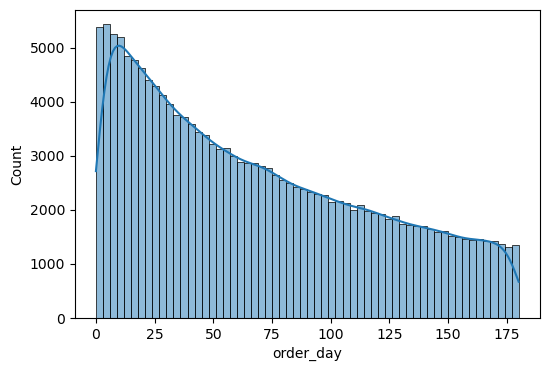

In [61]:
plt.figure(figsize=(6,4))
sns.histplot(df['order_day'], kde=True)

In [71]:
merged = df.merge(df_customers[["customer_id","identity_segment","engagement_tier"]], on="customer_id")
print(merged.groupby("identity_segment")["order_value"].mean().round(0))
print(merged.groupby("engagement_tier")["order_value"].count() / df_customers.groupby("engagement_tier").size())

identity_segment
Couple           1232.0
Family            787.0
Food Explorer     596.0
Office Worker     516.0
Student           405.0
Name: order_value, dtype: float64
engagement_tier
occasional     9.317128
power_user    54.439834
regular       19.791977
trial_only     3.770418
dtype: float64


In [72]:
merged = df.groupby("customer_id").size().reindex(df_customers["customer_id"], fill_value=0)
df_customers["n_orders"] = merged.values
df_customers["churned"] = df_customers["n_orders"] == 0   # crude proxy -- see caveat below
print(df_customers.groupby("engagement_tier")["churned"].mean())

engagement_tier
occasional    0.066422
power_user    0.007261
regular       0.031805
trial_only    0.140936
Name: churned, dtype: float64


In [73]:
last_order_day = df.groupby("customer_id")["order_day"].max()
df_customers["last_order_day"] = df_customers["customer_id"].map(last_order_day).fillna(0)
df_customers["gap_since_last_order"] = SIMULATION_DAYS - df_customers["last_order_day"]
# a large gap_since_last_order relative to their typical order_frequency_days = likely churned

In [74]:
df_customers.head()

,customer_id,identity_segment,engagement_tier,age,income,cost_preference,preferred_price_tier,group_size,explore_prob,preferred_rest_type,order_frequency_days,base_churn_hazard,location,n_orders,churned,last_order_day,gap_since_last_order
0,1000001,Couple,occasional,43,59373,631.0,Mid-range,1,0.30,Fine Dining,27.8,0.06,Whitefield,5,False,161.6,18.4
1,1000002,Office Worker,occasional,36,87255,365.0,Budget,2,0.20,Cafe,4.2,0.06,HSR,13,False,63.8,116.2
2,1000003,Couple,regular,28,102362,902.0,Mid-range,3,0.30,Cafe,4.8,0.03,Koramangala 5th Block,21,False,83.8,96.2
3,1000004,Family,power_user,55,178855,666.0,Mid-range,7,0.15,Casual Dining,1.3,0.01,Indiranagar,136,False,178.9,1.1
4,1000005,Student,regular,24,20379,324.0,Budget,3,0.35,Beverage Shop,6.2,0.03,Bannerghatta Road,9,False,43.6,136.4
